# Time series forecasting with Prophet

In [1]:

from modules import utils
utils.configure_plotly_template(showlegend=True)

## Load data

In [2]:
path = "../../../data/statsmodels/AirPassengers.parquet"

In [3]:
import pandas as pd

df = pd.read_parquet(path).asfreq('ME')
df.columns = ['values']

series = df['values']
series

1949-01-31    112
1949-02-28    118
             ... 
1960-11-30    390
1960-12-31    432
Freq: ME, Name: values, Length: 144, dtype: int64

## Prepare DataFrame for Prophet

In [4]:
df = pd.DataFrame({
    'ds': series.index,
    'y': series.values,
}, index=series.index)

df

,ds,y
1949-01-31,1949-01-31,112
1949-02-28,1949-02-28,118
...,...,...
1960-11-30,1960-11-30,390
1960-12-31,1960-12-31,432


## Model fit

In [5]:
from prophet import Prophet
from prophet.make_holidays import make_holidays_df

holidays = make_holidays_df(country='US', year_list=list(range(1960, 2020)))

model = Prophet(
    yearly_seasonality=True,
    holidays=holidays,
    seasonality_mode='multiplicative'  # or 'additive'
)

model.fit(df)

14:30:04 - cmdstanpy - INFO - Chain [1] start processing
14:30:05 - cmdstanpy - INFO - Chain [1] done processing


In [6]:
model.params

OrderedDict([('lp__', array([[504.189]])),
             ('k', array([[0.384835]])),
             ('m', array([[0.185815]])),
             ('delta',
              array([[ 5.42870e-08,  6.24460e-06,  1.25145e-02,  8.69326e-02,
                       1.41708e-05,  1.18608e-03,  4.10230e-08, -3.59351e-10,
                      -2.33091e-10, -2.21626e-08,  5.78547e-10, -8.26615e-09,
                       4.59462e-03,  1.50160e-01,  1.38214e-01,  1.73867e-06,
                       1.05550e-08, -1.68593e-08, -1.07334e-02, -7.24139e-02,
                      -5.56015e-02, -5.65617e-02, -2.96404e-08,  1.58965e-08,
                       2.34226e-01]])),
             ('sigma_obs', array([[0.0164136]])),
             ('beta',
              array([[-0.0617972 , -0.155452  ,  0.103451  ,  0.040846  , -0.0763804 ,
                      -0.00191198, -0.0468226 , -0.0255619 , -0.00713188,  0.102359  ,
                       0.135584  ,  0.0354446 ,  0.0209811 , -0.103524  , -0.0752532 ,
           

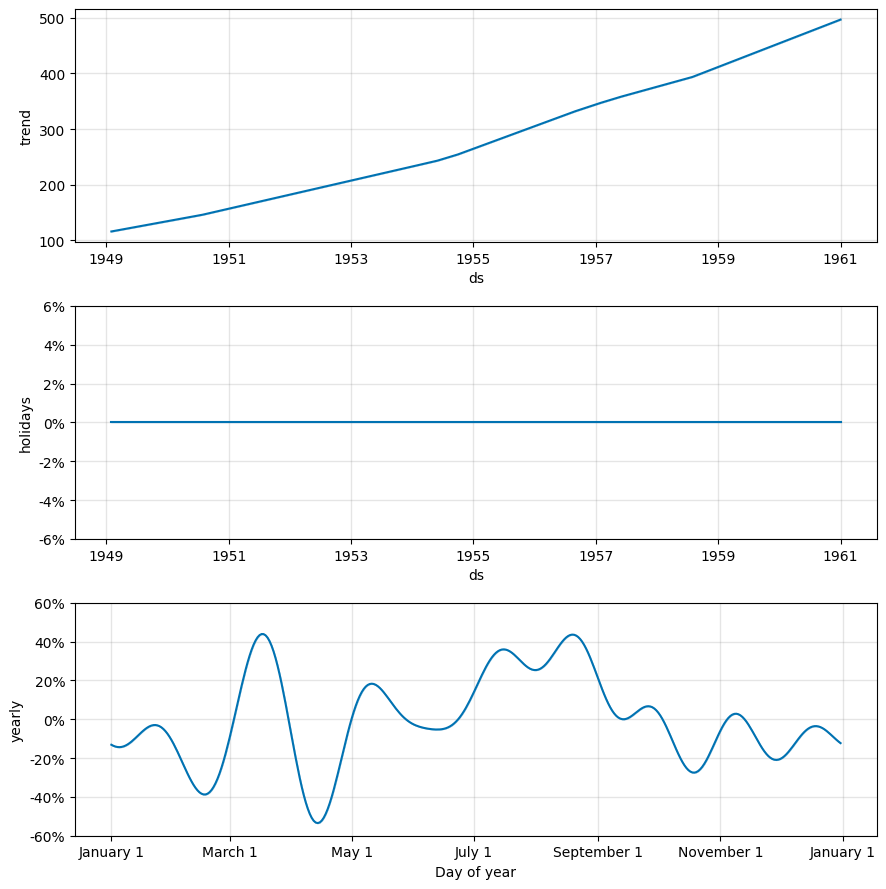

In [7]:
forecast = model.predict(df)
model.plot_components(forecast);

## Forecast

In [8]:
future = model.make_future_dataframe(periods=48, freq='ME')
forecast = model.predict(future)
forecast[['ds', 'yhat', 'yhat_lower', 'yhat_upper']].tail()

,ds,yhat,yhat_lower,yhat_upper
187,1964-08-31,803.657915,780.062148,827.880588
188,1964-09-30,685.324444,661.787913,709.123368
189,1964-10-31,610.362873,587.815300,631.609570
190,1964-11-30,526.198760,506.198815,546.787070
191,1964-12-31,584.240192,562.788198,605.103421


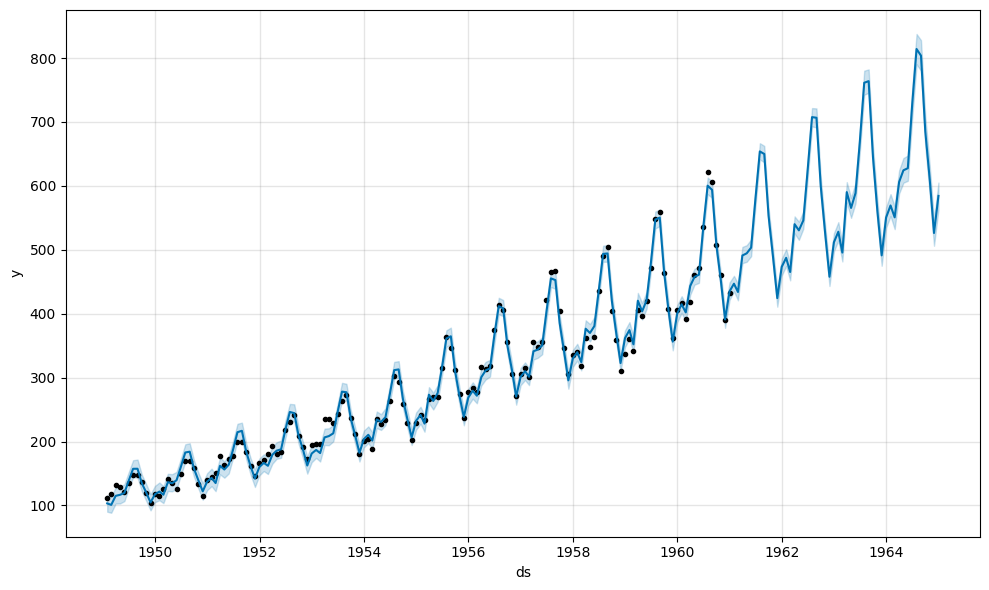

In [9]:
model.plot(forecast);

In [10]:
utils.plot_prophet_forecast(df['y'], forecast)

## Configuration

1. Prophet automatically detects trend and seasonality using changepoints.
2. You configure:

   * **Trend flexibility** (with or without change points)
   * **Additive vs. multiplicative** seasonality (`seasonality_mode`)
   * **Custom seasonalities** (optional)
   * **Holiday effects** (optional)


**📌 Rule of Thumb**

> “Prophet config is semi-automatic: trend and seasonal components are learned with flexible change points. You choose seasonal mode and horizon — minimal tuning required.”



**Seasonal decomposition visual insight only.**

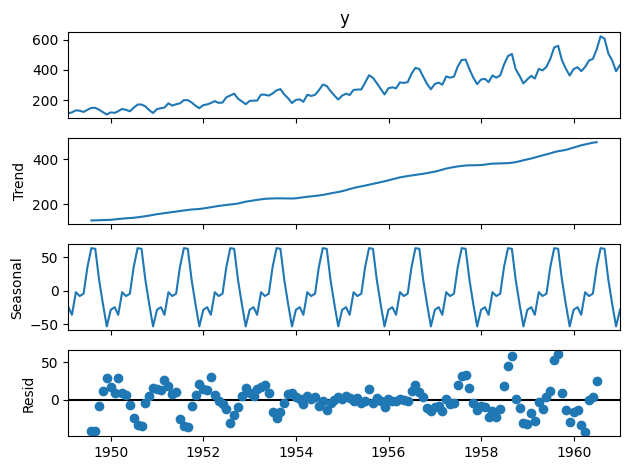

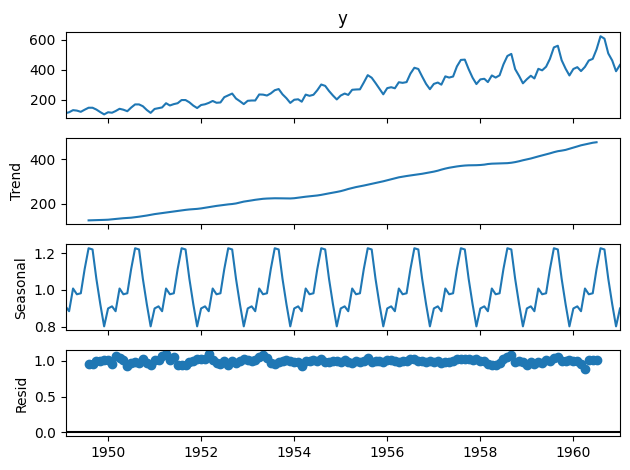

In [11]:
from statsmodels.tsa.seasonal import seasonal_decompose

seasonal_decompose(df['y'], model="additive", period=12).plot();
seasonal_decompose(df['y'], model="multiplicative", period=12).plot();

## Variation playground

### Prophet

In [12]:
from modules import utils

df = series.to_frame()

df = utils.get_model_forecast_prophet(df, column="values", mode="additive")
df = utils.get_model_forecast_prophet(df, column="values", mode="multiplicative")

df

14:30:32 - cmdstanpy - INFO - Chain [1] start processing
14:30:32 - cmdstanpy - INFO - Chain [1] done processing
14:30:32 - cmdstanpy - INFO - Chain [1] start processing
14:30:32 - cmdstanpy - INFO - Chain [1] done processing


,values,prophet_additive,prophet_multiplicative
1949-01-31,112.0,NaN,NaN
1949-02-28,118.0,NaN,NaN
...,...,...,...
1964-11-30,NaN,569.185858,526.198760
1964-12-31,NaN,598.116103,584.240192


In [13]:
df.plot()

### SARIMA vs Exponential Smoothing vs Prophet

In [14]:
import numpy as np

df = series.to_frame()

df_forecast = utils.get_model_forecast(
    df, "values", order=(12, 1, 1), horizon=96, forecast_exp=True
)
df_forecast = utils.get_model_forecast(
    df_forecast,
    "values",
    order=(0, 1, 1),
    seasonal_order=(0, 1, 1, 12),
    horizon=96,
    forecast_exp=True,
)
df_forecast = utils.get_model_forecast_exponential_smoothing(
    df_forecast,
    "values",
    horizon=96,
    class_config={"trend": "add", "seasonal": "mul", "seasonal_periods": 12},
)
df_forecast = utils.get_model_forecast_prophet(
    df_forecast, "values", mode="multiplicative", horizon=96
)

df_forecast.plot(color="variable")

/home/vscode/.local/lib/python3.10/site-packages/statsmodels/base/model.py:607: ConvergenceWarning:

Maximum Likelihood optimization failed to converge. Check mle_retvals

14:30:40 - cmdstanpy - INFO - Chain [1] start processing
14:30:40 - cmdstanpy - INFO - Chain [1] done processing


## Diagnostics and assumptions

Although Prophet is robust and doesn’t require stationarity or normal residuals, residual analysis helps confirm quality.

### Residual calculation

In [15]:
model = Prophet(
    yearly_seasonality=True,
    weekly_seasonality=False,
    daily_seasonality=False,
    holidays=holidays,
    seasonality_mode="multiplicative",
)

df = pd.DataFrame({
    'ds': series.index,
    'y': series.values
})

model.fit(df)

forecast = model.predict(df)

df_forecast = forecast.set_index("ds")[["yhat"]].join(df.set_index("ds"))
df_forecast["residuals"] = df_forecast["y"] - df_forecast["yhat"]

residuals = df_forecast["residuals"].dropna()
residuals

14:30:49 - cmdstanpy - INFO - Chain [1] start processing
14:30:49 - cmdstanpy - INFO - Chain [1] done processing


ds
1949-01-31     8.813402
1949-02-28    17.129738
                ...    
1960-11-30    -0.942365
1960-12-31    -2.879200
Name: residuals, Length: 144, dtype: float64

### Autocorrelation

#### Plot

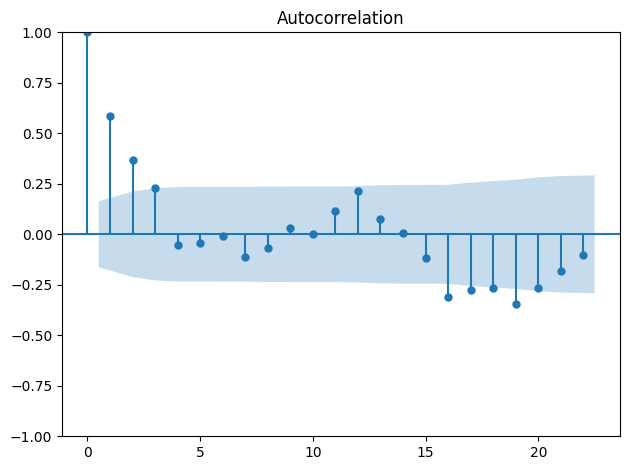

In [16]:
from statsmodels.graphics.tsaplots import plot_acf
plot_acf(residuals);

#### Test: Ljung-Box

In [17]:
from statsmodels.stats.diagnostic import acorr_ljungbox
acorr_ljungbox(residuals, lags=[10, 20, 30]).style

,lb_stat,lb_pvalue
10,81.462923,0.000000
20,166.170915,0.000000
30,216.914761,0.000000


### Normality

#### Plot

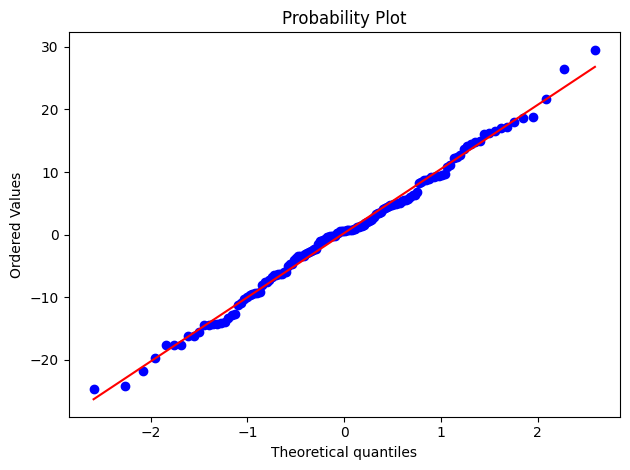

In [18]:
from scipy import stats
import matplotlib.pyplot as plt

fig, ax = plt.subplots()
stats.probplot(residuals, dist='norm', plot=ax);

#### Test: Jarque-Bera

In [19]:
from scipy.stats import jarque_bera
jarque_bera(residuals)

SignificanceResult(statistic=np.float64(0.061100917485669884), pvalue=np.float64(0.9699114903179887))

### Homoscedasticity

#### Plot

In [20]:
residuals.plot()

#### Test

In [21]:
from statsmodels.stats.diagnostic import het_arch
het_arch(residuals)

(np.float64(17.4169865493691),
 np.float64(0.0656314904547276),
 1.8375655956770998,
 0.06075228167271977)